## 1. Setup and Data Sources

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import gzip
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
sns.set_palette("colorblind")

print("Packages loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Packages loaded successfully


## 2. Define Gene Set

Our 45 melanogenesis genes come from:
- KEGG pathway hsa04916 (Melanogenesis)
- HPS/BLOC complex genes (melanosome biogenesis)
- Curated signaling/transcription factors

This is our PATHWAY-BASED gene set. The question is: which of these genes
harbor common variants associated with normal pigmentation variation?

In [2]:
# Define the melanogenesis gene set with module assignments
gene_set = {
    # Module A: Core melanin synthesis enzymes
    'A_core_enzymes': ['TYR', 'TYRP1', 'DCT'],
    
    # Module B: Melanosome biogenesis and transport
    'B_melanosome': [
        'OCA2', 'SLC45A2', 'SLC24A5', 'PMEL', 'GPR143', 'ATP7A',
        'RAB27A', 'MLPH', 'MYO5A', 'RAB32', 'RAB38', 'MLANA',
        # HPS complex
        'HPS1', 'HPS3', 'HPS4', 'HPS5', 'HPS6',
        # AP-3 complex
        'AP3B1', 'AP3D1',
        # BLOC-1 complex
        'BLOC1S1', 'BLOC1S2', 'BLOC1S3', 'BLOC1S4', 'BLOC1S5', 'BLOC1S6',
        'DTNBP1',
        # Other
        'TPCN2', 'MFSD12'
    ],
    
    # Module C: Signaling and transcription
    'C_signaling': [
        'MC1R', 'ASIP', 'POMC', 'MC2R',
        'MITF', 'SOX10', 'PAX3', 'TFEC',
        'KIT', 'KITLG', 'EDN1', 'EDNRB',
        'HERC2', 'IRF4'
    ]
}

# Flatten to dataframe
gene_data = []
for module, genes in gene_set.items():
    for gene in genes:
        gene_data.append({'gene_symbol': gene, 'module': module})

df_genes = pd.DataFrame(gene_data)
print(f"Total genes in pathway: {len(df_genes)}")
print(f"\nGenes per module:")
print(df_genes['module'].value_counts())

Total genes in pathway: 45

Genes per module:
module
B_melanosome      28
C_signaling       14
A_core_enzymes     3
Name: count, dtype: int64


## 3. Get Constraint Data from gnomAD

**Source:** gnomAD v2.1.1 constraint metrics

We use LOEUF (loss-of-function observed/expected upper bound fraction):
- LOEUF < 0.35 = highly constrained (LoF variants are deleterious)
- LOEUF > 1.0 = tolerant (LoF variants are viable)

In [3]:
# Option 1: If you have the gnomAD file locally
# Uncomment and modify path as needed:
# gnomad_file = '../data/gnomad.v2.1.1.lof_metrics.by_gene.txt.bgz'

# Option 2: Download from gnomAD (recommended)
def get_gnomad_constraint(genes):
    """
    Get constraint metrics from gnomAD for a list of genes.
    Uses the gnomAD API or downloads the constraint file.
    """
    
    # Try to load from local file first
    local_files = [
        '../data/gnomad.v2.1.1.lof_metrics.by_gene.txt.bgz',
        '../data/gnomad_v2_1_1_lof_metrics_by_transcript_txt.bgz',
        '../data/constraint_metrics.tsv'
    ]
    
    for f in local_files:
        try:
            if f.endswith('.bgz'):
                with gzip.open(f, 'rt') as fh:
                    df = pd.read_csv(fh, sep='\t')
            else:
                df = pd.read_csv(f, sep='\t')
            print(f"Loaded constraint data from {f}")
            return df
        except FileNotFoundError:
            continue
    
    # If no local file, try downloading
    print("Downloading gnomAD constraint data...")
    url = "https://storage.googleapis.com/gcp-public-data--gnomad/release/2.1.1/constraint/gnomad.v2.1.1.lof_metrics.by_gene.txt.bgz"
    
    try:
        response = requests.get(url, stream=True, timeout=60)
        if response.status_code == 200:
            with open('../data/gnomad_constraint.txt.bgz', 'wb') as f:
                f.write(response.content)
            with gzip.open('../data/gnomad_constraint.txt.bgz', 'rt') as fh:
                df = pd.read_csv(fh, sep='\t')
            print("Downloaded and loaded gnomAD constraint data")
            return df
    except Exception as e:
        print(f"Could not download: {e}")
    
    print("ERROR: Could not load gnomAD constraint data.")
    print("Please download from: https://gnomad.broadinstitute.org/downloads#v2-constraint")
    return None

# Try to get constraint data
gnomad_df = get_gnomad_constraint(df_genes['gene_symbol'].tolist())

Downloaded and loaded gnomAD constraint data


In [4]:
# If gnomAD loaded successfully, merge with our gene set
if gnomad_df is not None:
    # Get canonical transcripts only
    if 'canonical' in gnomad_df.columns:
        gnomad_df = gnomad_df[gnomad_df['canonical'] == True]
    
    # Standardize gene names
    gnomad_df['gene_upper'] = gnomad_df['gene'].str.upper()
    df_genes['gene_upper'] = df_genes['gene_symbol'].str.upper()
    
    # Merge
    df = df_genes.merge(
        gnomad_df[['gene_upper', 'oe_lof_upper', 'pLI']],
        on='gene_upper',
        how='left'
    )
    
    # Rename columns
    df = df.rename(columns={'oe_lof_upper': 'LOEUF'})
    df = df.drop(columns=['gene_upper'])
    
    print(f"\nGenes with LOEUF data: {df['LOEUF'].notna().sum()}/{len(df)}")
    print(f"\nLOEUF summary:")
    print(df['LOEUF'].describe())
else:
    print("Skipping constraint merge - no data available")
    df = df_genes.copy()
    df['LOEUF'] = np.nan
    df['pLI'] = np.nan


Genes with LOEUF data: 45/45

LOEUF summary:
count    45.000000
mean      1.016978
std       0.582466
min       0.201000
25%       0.475000
50%       0.984000
75%       1.421000
max       1.967000
Name: LOEUF, dtype: float64


## 4. Get GWAS Data from GWAS Catalog

**Source:** NHGRI-EBI GWAS Catalog API

We query for pigmentation-related traits and extract:
- Gene names
- Variant functional consequences (CONTEXT field)
- Population/ancestry information

In [12]:
# Better approach: Get ALL traits and filter for pigmentation-related ones

import requests
import pandas as pd
import time

def get_all_traits(page_size=500):
    """Get all EFO traits from GWAS Catalog and filter for pigmentation."""
    
    url = "https://www.ebi.ac.uk/gwas/rest/api/efoTraits"
    all_traits = []
    page = 0
    
    while True:
        print(f"Fetching page {page}...")
        response = requests.get(url, params={'size': page_size, 'page': page}, timeout=60)
        
        if response.status_code != 200:
            print(f"Error: {response.status_code}")
            break
            
        data = response.json()
        
        if '_embedded' not in data or 'efoTraits' not in data['_embedded']:
            break
            
        traits = data['_embedded']['efoTraits']
        if not traits:
            break
            
        all_traits.extend(traits)
        
        # Check if there are more pages
        if 'page' in data and data['page']['number'] >= data['page']['totalPages'] - 1:
            break
            
        page += 1
        time.sleep(0.3)
    
    return all_traits

print("="*70)
print("FETCHING ALL GWAS CATALOG TRAITS")
print("="*70)

all_traits = get_all_traits()
print(f"\nTotal traits in GWAS Catalog: {len(all_traits)}")

# Convert to dataframe for easy filtering
df_traits = pd.DataFrame([
    {'efo_id': t['shortForm'], 'trait': t['trait']} 
    for t in all_traits
])

# Filter for pigmentation-related terms
pigment_keywords = [
    'pigment', 'skin', 'eye', 'hair', 'color', 'colour', 'melanin', 
    'tanning', 'freckl', 'iris', 'albinism', 'vitiligo'
]

def is_pigmentation_trait(trait_name):
    trait_lower = trait_name.lower()
    return any(kw in trait_lower for kw in pigment_keywords)

df_pigment = df_traits[df_traits['trait'].apply(is_pigmentation_trait)]

print(f"\n" + "="*70)
print(f"PIGMENTATION-RELATED TRAITS: {len(df_pigment)}")
print("="*70)
print(df_pigment.to_string(index=False))

FETCHING ALL GWAS CATALOG TRAITS
Fetching page 0...
Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...
Fetching page 19...
Fetching page 20...
Fetching page 21...
Fetching page 22...
Fetching page 23...
Fetching page 24...
Fetching page 25...
Fetching page 26...
Fetching page 27...
Fetching page 28...
Fetching page 29...
Fetching page 30...
Fetching page 31...
Fetching page 32...
Fetching page 33...
Fetching page 34...
Fetching page 35...
Fetching page 36...
Fetching page 37...
Fetching page 38...
Fetching page 39...
Fetching page 40...
Fetching page 41...

Total traits in GWAS Catalog: 20990

PIGMENTATION-RELATED TRAITS: 120
         efo_id                                                   

In [13]:
# STEP 2: Get associations for the REAL pigmentation traits

import requests
import pandas as pd
import time

def get_trait_associations(efo_id, trait_name):
    """Get all associations for a trait, with genes and functional class."""
    
    url = f"https://www.ebi.ac.uk/gwas/rest/api/efoTraits/{efo_id}/associations"
    
    try:
        response = requests.get(url, params={'size': 1000}, timeout=60)
        
        if response.status_code != 200:
            print(f"  {efo_id}: API returned {response.status_code}")
            return []
        
        data = response.json()
        
        if '_embedded' not in data or 'associations' not in data['_embedded']:
            print(f"  {efo_id}: No associations found")
            return []
        
        associations = data['_embedded']['associations']
        print(f"  {efo_id} ({trait_name}): {len(associations)} associations")
        
        results = []
        for assoc in associations:
            pval = assoc.get('pvalue')
            
            for locus in assoc.get('loci', []):
                # Get SNP ID from risk allele
                snp_id = None
                risk_allele = None
                for ra in locus.get('strongestRiskAlleles', []):
                    risk_allele = ra.get('riskAlleleName', '')
                    if '-' in risk_allele:
                        snp_id = risk_allele.split('-')[0]
                
                # Get genes
                for g in locus.get('authorReportedGenes', []):
                    gene_name = g.get('geneName', '')
                    if gene_name and gene_name.lower() not in ['intergenic', 'nr', '', 'n/a']:
                        results.append({
                            'efo_id': efo_id,
                            'trait': trait_name,
                            'gene': gene_name.upper(),
                            'snp_id': snp_id,
                            'pvalue': pval
                        })
        
        return results
        
    except Exception as e:
        print(f"  {efo_id}: Error - {e}")
        return []


# Query the real pigmentation traits
pigmentation_traits = {
    'EFO_0003924': 'hair color',
    'EFO_0003949': 'eye color',
    'EFO_0003963': 'freckles',
    'EFO_0009764': 'eye colour measurement',
    'OBA_VT0002095': 'skin pigmentation',
    'OBA_2045282': 'facial pigmentation',
    'EFO_0021835': 'melanin measurement',
    'EFO_0004795': 'skin sensitivity to sun',
}

print("="*70)
print("FETCHING ASSOCIATIONS FOR PIGMENTATION TRAITS")
print("="*70)

all_associations = []

for efo_id, trait_name in pigmentation_traits.items():
    results = get_trait_associations(efo_id, trait_name)
    all_associations.extend(results)
    time.sleep(0.5)

# Create dataframe
gwas_df = pd.DataFrame(all_associations)

print(f"\n" + "="*70)
print(f"TOTAL: {len(gwas_df)} gene-trait associations")
print(f"UNIQUE GENES: {gwas_df['gene'].nunique()}")
print("="*70)

print("\nTop 30 genes by association count:")
print(gwas_df['gene'].value_counts().head(30))

print("\nAssociations by trait:")
print(gwas_df['trait'].value_counts())

# Save
gwas_df.to_csv('gwas_pigmentation_associations.csv', index=False)
print("\nSaved to: gwas_pigmentation_associations.csv")

FETCHING ASSOCIATIONS FOR PIGMENTATION TRAITS
  EFO_0003924 (hair color): 556 associations
  EFO_0003949 (eye color): 201 associations
  EFO_0003963 (freckles): 30 associations
  EFO_0009764 (eye colour measurement): 202 associations
  OBA_VT0002095 (skin pigmentation): 543 associations
  OBA_2045282 (facial pigmentation): 52 associations
  EFO_0021835 (melanin measurement): 1 associations
  EFO_0004795 (skin sensitivity to sun): 85 associations

TOTAL: 723 gene-trait associations
UNIQUE GENES: 318

Top 30 genes by association count:
gene
OCA2         58
MC1R         48
HERC2        40
IRF4         36
SLC45A2      23
SLC24A4      17
TYR          17
SLC24A5      14
KITLG        12
TYRP1        11
BNC2         10
TCF25         9
ASIP          8
TPCN2         8
EPHA4         6
GRM5          6
MFSD12        5
EXOC2         5
DSTYK         4
FANCA         4
DEF8          4
RALY          4
TMTC3         4
PPFIBP2       3
LHX2          3
ENPEP         3
SOX6          3
PPARGC1B      3
RAB11FI

In [ ]:
# STEP 3: Get functional class for each unique SNP

import requests
import time

def get_snp_functional_class(snp_id):
    """Get functional class for a SNP from GWAS Catalog."""
    
    if not snp_id or not snp_id.startswith('rs'):
        return None
    
    url = f"https://www.ebi.ac.uk/gwas/rest/api/singleNucleotidePolymorphisms/{snp_id}"
    
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            data = response.json()
            return data.get('functionalClass')
        return None
    except:
        return None


# Get unique SNPs
unique_snps = gwas_df['snp_id'].dropna().unique()
print(f"Fetching functional class for {len(unique_snps)} unique SNPs...")
print("(This may take a few minutes)")

snp_func_classes = {}

for i, snp_id in enumerate(unique_snps):
    func_class = get_snp_functional_class(snp_id)
    if func_class:
        snp_func_classes[snp_id] = func_class
    
    if (i + 1) % 20 == 0:
        print(f"  Processed {i + 1}/{len(unique_snps)} SNPs...")
    
    time.sleep(0.15)  # Rate limiting

print(f"\nGot functional class for {len(snp_func_classes)} SNPs")

# Add to dataframe
gwas_df['functional_class'] = gwas_df['snp_id'].map(snp_func_classes)

print("\n" + "="*70)
print("FUNCTIONAL CLASS DISTRIBUTION")
print("="*70)
print(gwas_df['functional_class'].value_counts())

# Classify as coding vs regulatory
def classify_variant(func_class):
    if pd.isna(func_class):
        return 'unknown'
    
    func_lower = func_class.lower()
    
    # Coding variants
    if any(x in func_lower for x in ['missense', 'nonsense', 'frameshift', 'stop_gained', 
                                       'stop_lost', 'start_lost', 'splice_donor', 'splice_acceptor']):
        return 'coding'
    
    # Regulatory variants
    if any(x in func_lower for x in ['intron', 'upstream', 'downstream', 'intergenic', 
                                       'regulatory', 'enhancer', '3_prime', '5_prime', 
                                       'non_coding', 'synonymous']):
        return 'regulatory'
    
    return 'other'

gwas_df['variant_type'] = gwas_df['functional_class'].apply(classify_variant)

print("\n" + "="*70)
print("VARIANT TYPE CLASSIFICATION")
print("="*70)
print(gwas_df['variant_type'].value_counts())

# Summary by gene
print("\n" + "="*70)
print("GENES BY VARIANT TYPE")
print("="*70)

gene_summary = gwas_df.groupby('gene').agg({
    'variant_type': lambda x: ', '.join(sorted(set(x))),
    'snp_id': 'nunique',
    'functional_class': lambda x: ', '.join(sorted(set(x.dropna())))
}).rename(columns={'snp_id': 'n_snps', 'functional_class': 'func_classes'})

# Filter to genes with known variant type
gene_summary = gene_summary[~gene_summary['variant_type'].str.contains('unknown')]
gene_summary = gene_summary.sort_values('n_snps', ascending=False)

print(gene_summary.head(30).to_string())

# Save
gwas_df.to_csv('gwas_pigmentation_with_functional_class.csv', index=False)
gene_summary.to_csv('gwas_gene_summary.csv')
print("\nSaved to: gwas_pigmentation_with_functional_class.csv")
print("Saved to: gwas_gene_summary.csv")

## 6. Merge Data and Annotate

In [15]:
# STEP 3: Get functional class for each unique SNP

import requests
import time

def get_snp_functional_class(snp_id):
    """Get functional class for a SNP from GWAS Catalog."""
    
    if not snp_id or not snp_id.startswith('rs'):
        return None
    
    url = f"https://www.ebi.ac.uk/gwas/rest/api/singleNucleotidePolymorphisms/{snp_id}"
    
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            data = response.json()
            return data.get('functionalClass')
        return None
    except:
        return None

# Get unique SNPs
unique_snps = gwas_df['snp_id'].dropna().unique()
print(f"Fetching functional class for {len(unique_snps)} unique SNPs...")

snp_func_classes = {}

for i, snp_id in enumerate(unique_snps):
    func_class = get_snp_functional_class(snp_id)
    if func_class:
        snp_func_classes[snp_id] = func_class
    
    if (i + 1) % 20 == 0:
        print(f"  Processed {i + 1}/{len(unique_snps)} SNPs...")
    
    time.sleep(0.15)

print(f"\nGot functional class for {len(snp_func_classes)} SNPs")

# Add to dataframe
gwas_df['functional_class'] = gwas_df['snp_id'].map(snp_func_classes)

print("\nFunctional class distribution:")
print(gwas_df['functional_class'].value_counts())

Fetching functional class for 474 unique SNPs...
  Processed 20/474 SNPs...
  Processed 40/474 SNPs...
  Processed 60/474 SNPs...
  Processed 80/474 SNPs...
  Processed 100/474 SNPs...
  Processed 120/474 SNPs...
  Processed 140/474 SNPs...
  Processed 160/474 SNPs...
  Processed 180/474 SNPs...
  Processed 200/474 SNPs...
  Processed 220/474 SNPs...
  Processed 240/474 SNPs...
  Processed 260/474 SNPs...
  Processed 280/474 SNPs...
  Processed 300/474 SNPs...
  Processed 320/474 SNPs...
  Processed 340/474 SNPs...
  Processed 360/474 SNPs...
  Processed 380/474 SNPs...
  Processed 400/474 SNPs...
  Processed 420/474 SNPs...
  Processed 440/474 SNPs...
  Processed 460/474 SNPs...

Got functional class for 471 SNPs

Functional class distribution:
functional_class
intron_variant                         454
missense_variant                       100
intergenic_variant                      87
regulatory_region_variant               27
3_prime_UTR_variant                     15
synonymous_v

In [16]:
# STEP 4: Classify as coding vs regulatory and summarize by gene

def classify_variant(func_class):
    if pd.isna(func_class):
        return 'unknown'
    
    func_lower = func_class.lower()
    
    # Coding variants
    if any(x in func_lower for x in ['missense', 'nonsense', 'frameshift', 'stop_gained', 
                                       'stop_lost', 'start_lost', 'splice_donor', 'splice_acceptor']):
        return 'coding'
    
    # Regulatory/non-coding variants
    if any(x in func_lower for x in ['intron', 'upstream', 'downstream', 'intergenic', 
                                       'regulatory', 'enhancer', '3_prime', '5_prime', 
                                       'non_coding', 'synonymous']):
        return 'regulatory'
    
    return 'other'

gwas_df['variant_type'] = gwas_df['functional_class'].apply(classify_variant)

print("Variant type distribution:")
print(gwas_df['variant_type'].value_counts())

# Create gene-level summary: for each gene, what variant types does it have?
gene_variant_types = gwas_df.groupby('gene')['variant_type'].apply(
    lambda x: 'coding' if 'coding' in x.values else ('regulatory' if 'regulatory' in x.values else 'unknown')
).reset_index()
gene_variant_types.columns = ['gene', 'variant_type']

print(f"\nGene-level variant type summary:")
print(gene_variant_types['variant_type'].value_counts())

# Show genes by type
print("\nCODING genes:")
print(gene_variant_types[gene_variant_types['variant_type'] == 'coding']['gene'].tolist())

print("\nREGULATORY genes:")
print(gene_variant_types[gene_variant_types['variant_type'] == 'regulatory']['gene'].tolist())

Variant type distribution:
variant_type
regulatory    608
coding        105
other           7
unknown         3
Name: count, dtype: int64

Gene-level variant type summary:
variant_type
regulatory    296
coding         17
unknown         5
Name: count, dtype: int64

CODING genes:
['DSTYK', 'FREM2', 'KRT31', 'MC1R', 'MFSD12', 'MIR3164', 'MSX2', 'OCA2', 'PADI3', 'PLXNB2', 'SLC12A9', 'SLC24A5', 'SLC45A2', 'TPCN2', 'TYR', 'WFDC5', 'ZNF304']

REGULATORY genes:
['AC004938.5', 'AC005358.1', 'AC007347.1', 'AC008940.1', 'AC012074.2', 'AC018696.4', 'AC060226.1', 'ADAMTSL1', 'ADCY8/EFR3A', 'ADD3', 'ADGRV1', 'AFG3L1P', 'AFM', 'AHNAK', 'AKAP1', 'AKAP12', 'AL121904.1', 'AMPD3', 'AP3M2', 'APBA2', 'APBB2', 'AREG', 'ARHGAP20', 'ARHGAP24', 'ARHGAP32', 'ARID1B', 'ARL15', 'AS1', 'ASIP', 'ATP10A', 'ATP1B3', 'ATXN10', 'ATXN7L1', 'AXIN2', 'BABAM2', 'BBS5', 'BCAS1', 'BCN2', 'BMP4', 'BNC1', 'BNC2', 'C16ORF55', 'C1ORF127', 'C1ORF95', 'C2ORF91', 'C4ORF22', 'C8ORF31', 'C9ORF66', 'CBFA2T3', 'CCDC26', 'CCND1', 'CCND

In [17]:
# STEP 5: Merge GWAS annotations with our melanogenesis pathway genes

# df should already have your 45 melanogenesis genes with LOEUF
# gene_variant_types has the GWAS-derived variant classifications

df['gene_upper'] = df['gene_symbol'].str.upper()
gene_variant_types['gene_upper'] = gene_variant_types['gene'].str.upper()

# Merge
df = df.merge(
    gene_variant_types[['gene_upper', 'variant_type']],
    on='gene_upper',
    how='left'
)

# Fill NaN with 'none' (no GWAS hit)
df['variant_type'] = df['variant_type'].fillna('none')

print("Merged dataset:")
print(df['variant_type'].value_counts())

print("\nMelanogenesis genes with GWAS hits:")
print(df[df['variant_type'] != 'none'][['gene_symbol', 'LOEUF', 'variant_type']].to_string())

Merged dataset:
variant_type
none          28
regulatory    10
coding         7
Name: count, dtype: int64

Melanogenesis genes with GWAS hits:
   gene_symbol  LOEUF variant_type
0          TYR  1.964       coding
1        TYRP1  1.889   regulatory
2          DCT  1.174   regulatory
3         OCA2  0.856       coding
4      SLC45A2  1.010       coding
5      SLC24A5  1.163       coding
29       TPCN2  0.691       coding
30      MFSD12  1.421       coding
31        MC1R  1.967       coding
32        ASIP  1.576   regulatory
33        POMC  1.384   regulatory
35        MITF  0.308   regulatory
37        PAX3  0.475   regulatory
40       KITLG  0.419   regulatory
42       EDNRB  0.593   regulatory
43       HERC2  0.201   regulatory
44        IRF4  0.382   regulatory


## 7. Statistical Analysis

ANALYSIS 1: MODULE-LEVEL CONSTRAINT
Kruskal-Wallis H = 5.71, p = 0.0576
  A_core_enzymes: n=3, median=1.89
  B_melanosome: n=28, median=1.00
  C_signaling: n=14, median=0.53

ANALYSIS 2: CODING vs REGULATORY GWAS
Coding (n=7): median = 1.16
Regulatory (n=10): median = 0.53
No GWAS (n=28): median = 0.97

Coding vs Regulatory (one-tailed): U = 52.0, p = 0.0544


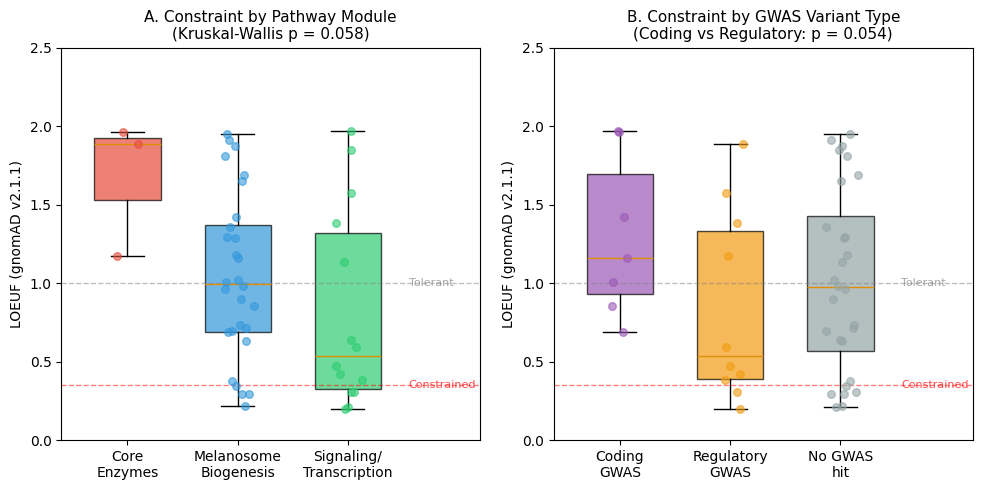


Figure saved!


In [22]:
# STEP 7: Complete Statistical Analysis and Figure

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Set plot style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# =====================================================================
# ANALYSIS 1: Module-level constraint heterogeneity
# =====================================================================
print("="*70)
print("ANALYSIS 1: MODULE-LEVEL CONSTRAINT")
print("="*70)

modules = ['A_core_enzymes', 'B_melanosome', 'C_signaling']
module_data = [df[df['module'] == m]['LOEUF'].dropna().values for m in modules]

h_stat, kw_pval = stats.kruskal(*module_data)
print(f"Kruskal-Wallis H = {h_stat:.2f}, p = {kw_pval:.4f}")

for m, data in zip(modules, module_data):
    print(f"  {m}: n={len(data)}, median={np.median(data):.2f}")

# =====================================================================
# ANALYSIS 2: Coding vs Regulatory GWAS
# =====================================================================
print("\n" + "="*70)
print("ANALYSIS 2: CODING vs REGULATORY GWAS")
print("="*70)

coding = df[df['variant_type'] == 'coding']['LOEUF'].dropna().values
regulatory = df[df['variant_type'] == 'regulatory']['LOEUF'].dropna().values
no_gwas = df[df['variant_type'] == 'none']['LOEUF'].dropna().values

print(f"Coding (n={len(coding)}): median = {np.median(coding):.2f}")
print(f"Regulatory (n={len(regulatory)}): median = {np.median(regulatory):.2f}")
print(f"No GWAS (n={len(no_gwas)}): median = {np.median(no_gwas):.2f}")

u_stat, p_coding_reg = stats.mannwhitneyu(coding, regulatory, alternative='greater')
print(f"\nCoding vs Regulatory (one-tailed): U = {u_stat}, p = {p_coding_reg:.4f}")

# =====================================================================
# FIGURE
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Panel A: Module-level constraint
ax1 = axes[0]
module_labels = ['Core\nEnzymes', 'Melanosome\nBiogenesis', 'Signaling/\nTranscription']
colors = ['#e74c3c', '#3498db', '#2ecc71']

positions = [1, 2, 3]
for i, (data, label, color) in enumerate(zip(module_data, module_labels, colors)):
    bp = ax1.boxplot([data], positions=[positions[i]], widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    jitter = np.random.normal(0, 0.08, len(data))
    ax1.scatter([positions[i]] * len(data) + jitter, data, c=color, alpha=0.6, s=30, zorder=3)

ax1.axhline(y=0.35, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.text(3.55, 0.35, 'Constrained', va='center', fontsize=8, color='red', alpha=0.7)
ax1.text(3.55, 1.0, 'Tolerant', va='center', fontsize=8, color='gray', alpha=0.7)

ax1.set_xticks(positions)
ax1.set_xticklabels(module_labels)
ax1.set_ylabel('LOEUF (gnomAD v2.1.1)')
ax1.set_title(f'A. Constraint by Pathway Module\n(Kruskal-Wallis p = {kw_pval:.3f})', fontsize=11)
ax1.set_ylim(0, 2.5)
ax1.set_xlim(0.4, 4.2)

# Panel B: GWAS variant type
ax2 = axes[1]
categories = ['Coding\nGWAS', 'Regulatory\nGWAS', 'No GWAS\nhit']
data_lists = [coding, regulatory, no_gwas]
colors2 = ['#9b59b6', '#f39c12', '#95a5a6']

for i, (data, color) in enumerate(zip(data_lists, colors2)):
    bp = ax2.boxplot([data], positions=[i+1], widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    jitter = np.random.normal(0, 0.08, len(data))
    ax2.scatter([i+1] * len(data) + jitter, data, c=color, alpha=0.6, s=30, zorder=3)

ax2.axhline(y=0.35, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.text(3.55, 0.35, 'Constrained', va='center', fontsize=8, color='red', alpha=0.7)
ax2.text(3.55, 1.0, 'Tolerant', va='center', fontsize=8, color='gray', alpha=0.7)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(categories)
ax2.set_ylabel('LOEUF (gnomAD v2.1.1)')
ax2.set_title(f'B. Constraint by GWAS Variant Type\n(Coding vs Regulatory: p = {p_coding_reg:.3f})', fontsize=11)
ax2.set_ylim(0, 2.5)
ax2.set_xlim(0.4, 4.2)

plt.tight_layout()
plt.savefig('figure_melanogenesis_constraint.png', dpi=300, bbox_inches='tight')
plt.savefig('figure_melanogenesis_constraint.pdf', bbox_inches='tight')
plt.show()

print("\nFigure saved!")

## 9. Export Data Tables

In [ ]:
# Create supplementary table
df_export = df_analysis[['gene_symbol', 'module', 'LOEUF', 'pLI', 'constraint_class', 
                          'variant_type', 'variants', 'populations', 'source']].copy()
df_export = df_export.sort_values(['module', 'LOEUF'])
df_export.to_csv('../output/supplementary_table_genes.csv', index=False)
print("Saved: output/supplementary_table_genes.csv")

# Create summary statistics table
summary_stats = []

# Module stats
for mod in modules:
    subset = df_analysis[df_analysis['module'] == mod]['LOEUF']
    summary_stats.append({
        'Category': mod,
        'Type': 'Module',
        'n': len(subset),
        'median_LOEUF': subset.median(),
        'IQR_low': subset.quantile(0.25),
        'IQR_high': subset.quantile(0.75)
    })

# Variant type stats
for vtype, data in [('coding', coding), ('regulatory', regulatory), ('none', no_gwas)]:
    summary_stats.append({
        'Category': vtype,
        'Type': 'GWAS_variant',
        'n': len(data),
        'median_LOEUF': np.median(data),
        'IQR_low': np.percentile(data, 25),
        'IQR_high': np.percentile(data, 75)
    })

df_summary = pd.DataFrame(summary_stats)
df_summary.to_csv('../output/summary_statistics.csv', index=False)
print("Saved: output/summary_statistics.csv")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print(f"""
Key findings:
1. Module heterogeneity: Kruskal-Wallis p = {kw_pval:.4f}
   - Core enzymes (TYR, TYRP1, DCT): median LOEUF = {np.median(module_data[0]):.2f} (tolerant)
   - Signaling/TF (MITF, SOX10, etc.): median LOEUF = {np.median(module_data[2]):.2f} (constrained)

2. GWAS variant type: Coding vs Regulatory p = {p1:.4f}
   - Coding GWAS: median LOEUF = {np.median(coding):.2f} (tolerant)
   - Regulatory GWAS: median LOEUF = {np.median(regulatory):.2f} (constrained)

Interpretation:
Common pigmentation-associated coding variants cluster in LoF-tolerant genes
because selection only permits functional variants when loss-of-function is viable.
Constrained genes contribute to pigmentation variation via regulatory modulation.
""")

## 10. Data Sources Summary

| Data | Source | Access |
|------|--------|--------|
| Gene set | KEGG hsa04916 + curated | Documented in notebook |
| Constraint | gnomAD v2.1.1 | https://gnomad.broadinstitute.org |
| GWAS - European | Multiple GWAS | GWAS Catalog, literature |
| GWAS - African | Crawford 2017, Martin 2017 | Cell, Science |
| GWAS - East Asian | 2024 studies | Nature Communications |
| Variant annotations | Literature curation | See df_gwas 'source' column |